<a href="https://colab.research.google.com/github/Hafiz-Fast/News-Bias-Analyzer-Stance-and-Sentiment-Analysis-/blob/logistig-regression%2Frandom-forest/NLP_Logistic_Regression_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Logistic Regression & Random Forest Classifier

In [1]:
!pip install pandas numpy scikit-learn nltk joblib
import pandas as pd
import numpy as np
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [2]:
from google.colab import files
uploaded = files.upload()


Saving English Dataset.zip to English Dataset.zip
Saving Urdu_data_reduced.pkl to Urdu_data_reduced.pkl


In [3]:
import pickle

urdu_df = pd.read_pickle('Urdu_data_reduced.pkl')
print("Urdu dataset loaded")
print(urdu_df.shape)
print(urdu_df.columns)
urdu_df.head()


Urdu dataset loaded
(79982, 4)
Index(['Headline', 'News Text', 'Stance', 'sentiment'], dtype='object')


,Headline,News Text,Stance,sentiment
0,جنوبی افریقا اور انگلینڈ کے درمیان پہلا ون ڈے ...,کیپ ٹائونجسارت نیوزجنوبی افریقا اور انگلینڈ کی...,unrelated,negative
1,پاکستان اٹو پارٹس شو 2017 مارچ سے شروع ہوگا,کراچی اردو پوائنٹ اخبارتازہ ترین لائن 01 مارچ2...,unrelated,neutral
2,پاکستانی میسی شین وارن بننے کا خواہشمندیاسر شا...,دبئی اردو پوائنٹ تاز ترین اخبار 19نومبر 2014ء ...,agree,neutral
3,کے جوتے کا نمبر کتنا ہےرمیز راجہ نے محمد عرفان...,شارجہ ڈیلی پاکستان لائن ملتان سلطانز کے فاسٹ ب...,discuss,positive
4,دماغ کو چکرا دینے والا بصری واہمہ,یہ کل وائرل ہونے والے بصری واہمے کی تصویر ہے ج...,unrelated,negative


In [4]:
urdu_df = urdu_df.rename(columns={'News Text': 'articleBody'})
urdu_df = urdu_df[['Headline', 'articleBody', 'Stance', 'sentiment']]

In [5]:
import zipfile, os

with zipfile.ZipFile('English Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/english_dataset')

os.listdir('/content/english_dataset')


['EngBal_data.csv', 'EngBal_data.pkl']

In [6]:
english_df = pd.read_pickle('/content/english_dataset/EngBal_data.pkl')
print("English dataset loaded")
print(english_df.shape)
print(english_df.columns)
english_df.head()


English dataset loaded
(39980, 3)
Index(['Headline', 'articleBody', 'Stance'], dtype='object')


,Headline,articleBody,Stance
0,Kim Jong-un relying on ‘cobra wine’ after prob...,The sound of 10 or 11 shots from the gun of Fe...,unrelated
1,Durex Is Not Making Pumpkin Spice Condoms Afte...,Tiger Woods divorced Swedish model Elin Nordeg...,unrelated
2,Apple Watch Specs Tipped; Said to Feature 512M...,While hype around the Apple Watch has remained...,unrelated
3,IRAQI AND KURDISH MEDIA REPORTS: ISIS FIGHTERS...,With the threat of an ISIS terror attack becom...,discuss
4,"No, Saudi TV Did Not Blur Out Images of Michel...","Update: Since the publication of this article,...",unrelated


In [7]:
english_df['sentiment'] = 'neutral'
english_df = english_df[['Headline', 'articleBody', 'Stance', 'sentiment']]


In [8]:
print("Urdu dataset size:", len(urdu_df))
print("English dataset size:", len(english_df))


Urdu dataset size: 79982
English dataset size: 39980


In [9]:
sample_size = min(len(urdu_df), len(english_df))
urdu_sample = urdu_df.sample(sample_size, random_state=42)
english_sample = english_df.sample(sample_size, random_state=42)

combined_df = pd.concat([urdu_sample, english_sample], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)


In [10]:
sample_size = min(len(urdu_df), len(english_df))

urdu_sample = urdu_df.sample(sample_size, random_state=42)
english_sample = english_df.sample(sample_size, random_state=42)

combined_df = pd.concat([urdu_sample, english_sample], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Combined dataset created successfully!")
print("Shape:", combined_df.shape)
print("Columns:", combined_df.columns)
print("\nStance value counts:")
print(combined_df['Stance'].value_counts())

combined_df.head()


Combined dataset created successfully!
Shape: (79960, 4)
Columns: Index(['Headline', 'articleBody', 'Stance', 'sentiment'], dtype='object')

Stance value counts:
Stance
unrelated    54083
discuss      12465
agree        11397
disagree      2015
Name: count, dtype: int64


,Headline,articleBody,Stance,sentiment
0,Dog found abandoned at Scottish train station ...,Islamic State militants have released a video ...,unrelated,neutral
1,ہالی ووڈ فلم ایونجرز4 کا نیا سنسنی خیز ٹریلر ر...,نیویارکاردو پوائنٹ اخبارتازہ ترین لائن 05 مارچ...,discuss,neutral
2,سری لنکن ٹیم کے شکرگزار ہیں سرفراز احمد,پاکستان مد پر قومی ٹیم کے کپتان سرفراز احمد نے...,agree,positive
3,محمد حفیظ فٹنس مسائل کی وجہ سے پی ایس ایل سے باہر,دبئی ویب ڈیسک لاہور قلندرز کے کپتان محمد حفیظ ...,discuss,positive
4,"Islamic State, in video titled ""A Message to A...",Militants from Islamic State (Isis) claimed to...,discuss,neutral


In [11]:
import re
from sklearn.model_selection import train_test_split

# Add a simple language label
# urdu entries sampled first, and then english entries
combined_df['language'] = [0]*len(urdu_sample) + [1]*len(english_sample)

#  combine headline and article body into one text column
combined_df['text'] = combined_df['Headline'].astype(str) + " " + combined_df['articleBody'].astype(str)

#  cleaning text
def clean_text(text):
    text = re.sub(r'\s+', ' ', text) # remove extra spaces
    text = re.sub(r'[^\w\s\u0600-\u06FF]', '', text)  # keep Urdu & English letters/numbers
    text = text.strip()
    return text

combined_df['clean_text'] = combined_df['text'].apply(clean_text)

#   Split into features (X) and labels (y)
X = combined_df['clean_text']
y = combined_df['language']

#  Train–test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data split successful!")
print("Train size:", len(X_train))
print("Test size:", len(X_test))


Data split successful!
Train size: 63968
Test size: 15992


In [12]:
# Combining headline + article body into one text
combined_df['full_text'] = combined_df['Headline'] + " " + combined_df['articleBody']

# checking for missing values
print("Missing values:")
print(combined_df.isnull().sum())

# if missing values, fill it with empty strings
combined_df['full_text'] = combined_df['full_text'].fillna('')
combined_df['Stance'] = combined_df['Stance'].fillna('unrelated')
combined_df['sentiment'] = combined_df['sentiment'].fillna('neutral')

# creating train/test split again (from combined_df)
from sklearn.model_selection import train_test_split

X = combined_df['full_text']
y_stance = combined_df['Stance']
y_sentiment = combined_df['sentiment']

X_train, X_test, y_stance_train, y_stance_test, y_sentiment_train, y_sentiment_test = train_test_split(
    X, y_stance, y_sentiment,
    test_size=0.2,
    random_state=42,
    stratify=y_stance  # keeps class balance
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Missing values:
Headline       0
articleBody    0
Stance         0
sentiment      0
language       0
text           0
clean_text     0
full_text      0
dtype: int64
Train: 63968, Test: 15992


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,  # use top 5000 words
    ngram_range=(1, 2),  # unigrams + bigrams
    stop_words=None,  # None for multilingual (Urdu + English)
    min_df=2,  # ignore words that appear in less than 2 documents
    max_df=0.8  # ignore words that appear in more than 80% of documents
)

# Fit on training data and transform
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF vectorization complete")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Test features shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

TF-IDF vectorization complete
Training features shape: (63968, 5000)
Test features shape: (15992, 5000)
Vocabulary size: 5000


Stance Detection - Logistic regression results

Accuracy: 0.5196

Classification Report:
              precision    recall  f1-score   support

       agree       0.31      0.56      0.40      2279
    disagree       0.09      0.54      0.16       403
     discuss       0.45      0.58      0.51      2493
   unrelated       0.85      0.50      0.63     10817

    accuracy                           0.52     15992
   macro avg       0.43      0.54      0.42     15992
weighted avg       0.69      0.52      0.56     15992



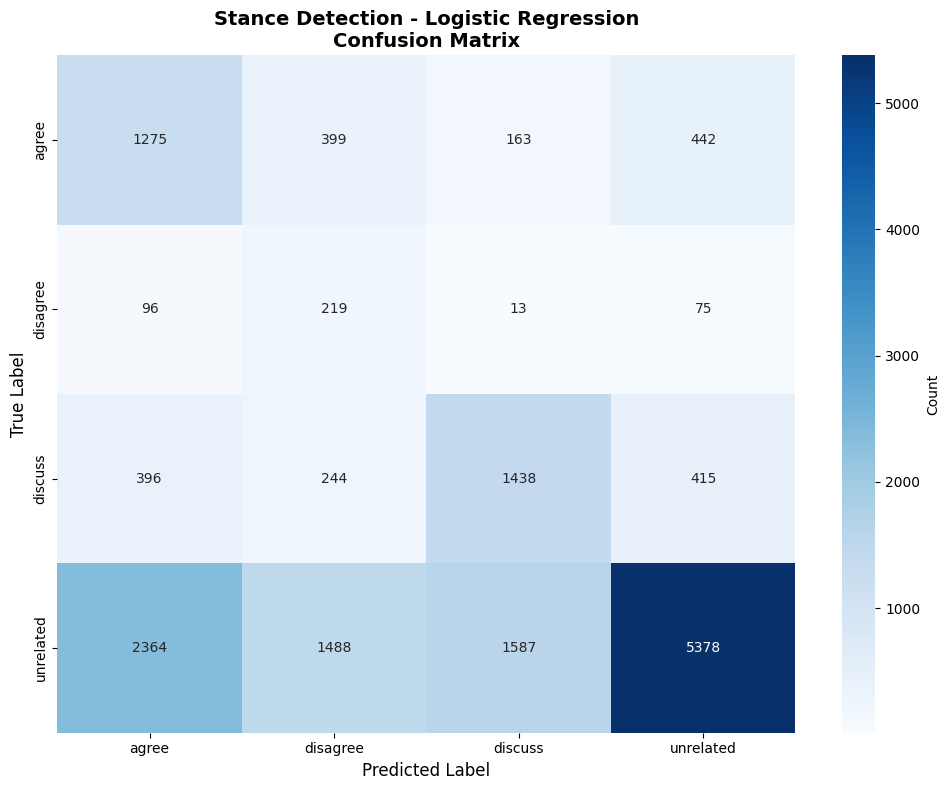


Logistic Regression training complete!


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


lr_stance = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # handles class imbalance
)

lr_stance.fit(X_train_tfidf, y_stance_train)

# Predict on test set
y_stance_pred = lr_stance.predict(X_test_tfidf)

print("Stance Detection - Logistic regression results")
print(f"\nAccuracy: {accuracy_score(y_stance_test, y_stance_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_stance_test, y_stance_pred))

# Confusion matrix
cm = confusion_matrix(y_stance_test, y_stance_pred, labels=lr_stance.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_stance.classes_,
            yticklabels=lr_stance.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Stance Detection - Logistic Regression\nConfusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nLogistic Regression training complete!")

Sentiment analysis - random forest results

Accuracy: 0.7230

Classification Report:
              precision    recall  f1-score   support

    negative       0.43      0.93      0.59      2166
     neutral       1.00      0.70      0.82     11630
    positive       0.46      0.66      0.54      2196

    accuracy                           0.72     15992
   macro avg       0.63      0.76      0.65     15992
weighted avg       0.85      0.72      0.75     15992



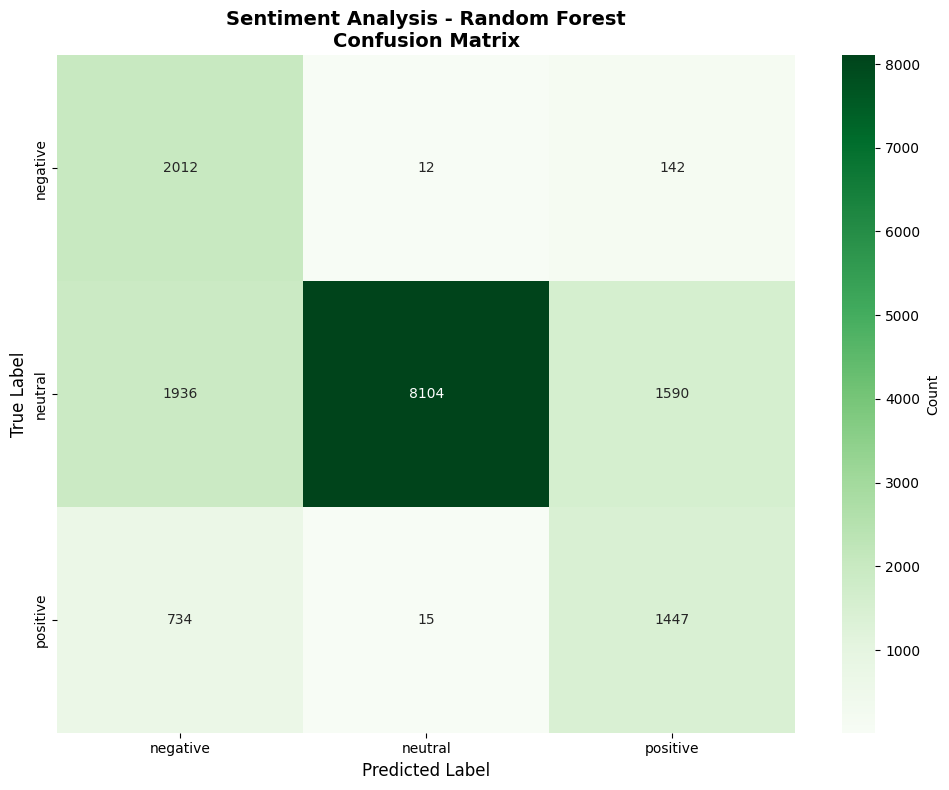


Random Forest training complete!


In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_sentiment = RandomForestClassifier(
    n_estimators=100,  # number of trees
    random_state=42,
    class_weight='balanced',  # handles class imbalance
    max_depth=20,  # prevent overfitting
    n_jobs=-1  # use all CPU cores
)

rf_sentiment.fit(X_train_tfidf, y_sentiment_train)

# Predict on test set
y_sentiment_pred = rf_sentiment.predict(X_test_tfidf)

print("Sentiment analysis - random forest results")
print(f"\nAccuracy: {accuracy_score(y_sentiment_test, y_sentiment_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_sentiment_test, y_sentiment_pred))

# Confusion matrix
cm_sentiment = confusion_matrix(y_sentiment_test, y_sentiment_pred, labels=rf_sentiment.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_sentiment, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_sentiment.classes_,
            yticklabels=rf_sentiment.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Sentiment Analysis - Random Forest\nConfusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nRandom Forest training complete!")

In [17]:
import joblib

joblib.dump(lr_stance, 'logistic_regression_stance.pkl')
joblib.dump(rf_sentiment, 'random_forest_sentiment.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Models saved successfully!")
print("Files created:")
print("   - logistic_regression_stance.pkl")
print("   - random_forest_sentiment.pkl")
print("   - tfidf_vectorizer.pkl")

Models saved successfully!
Files created:
   - logistic_regression_stance.pkl
   - random_forest_sentiment.pkl
   - tfidf_vectorizer.pkl


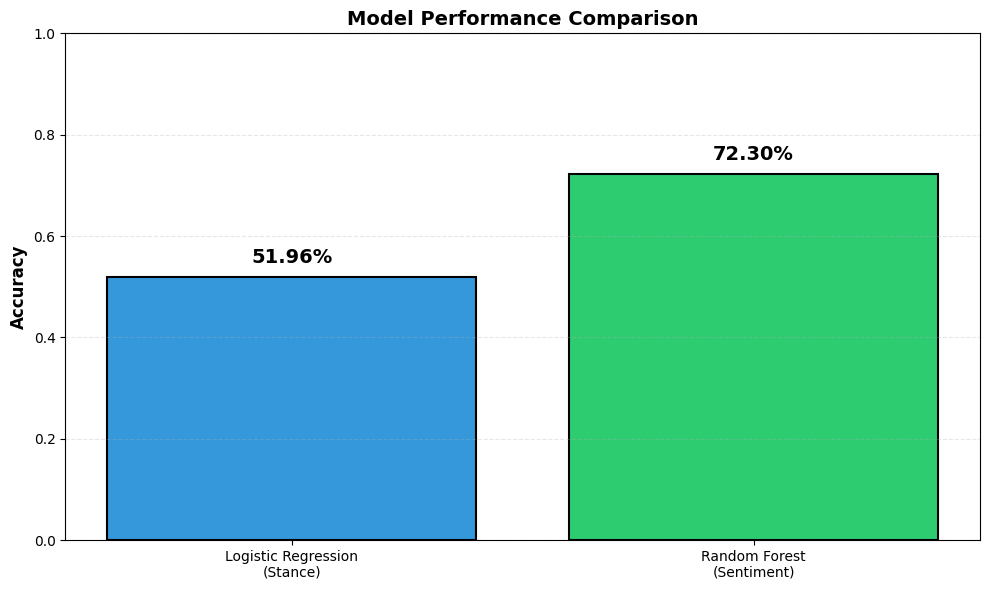


Summary:
Stance Detection (LR): 51.96%
Sentiment Analysis (RF): 72.30%


In [18]:
# Compare both models
results = {
    'Model': ['Logistic Regression\n(Stance)', 'Random Forest\n(Sentiment)'],
    'Accuracy': [0.5196, 0.7230],
    'Task': ['Stance Detection', 'Sentiment Analysis']
}

plt.figure(figsize=(10, 6))
bars = plt.bar(results['Model'], results['Accuracy'], color=['#3498db', '#2ecc71'], edgecolor='black', linewidth=1.5)

# Add accuracy labels on bars
for i, (bar, acc) in enumerate(zip(bars, results['Accuracy'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"Stance Detection (LR): {results['Accuracy'][0]:.2%}")
print(f"Sentiment Analysis (RF): {results['Accuracy'][1]:.2%}")

In [19]:
def predict_news_analysis(headline, article_body):

    # Combine text
    full_text = headline + " " + article_body

    # Transform to TF-IDF
    text_tfidf = tfidf.transform([full_text])

    # Predict
    stance = lr_stance.predict(text_tfidf)[0]
    stance_proba = lr_stance.predict_proba(text_tfidf)[0]

    sentiment = rf_sentiment.predict(text_tfidf)[0]
    sentiment_proba = rf_sentiment.predict_proba(text_tfidf)[0]

    print(" News analysis:")
    print(f"\n Headline: {headline}")
    print(f"\n Article: {article_body[:200]}...")
    print("\n")
    print(f" Stance: {stance.upper()}")
    print(f"   Confidence: {max(stance_proba):.2%}")
    print(f"\n Sentiment: {sentiment.upper()}")
    print(f"   Confidence: {max(sentiment_proba):.2%}")

    return stance, sentiment

# sample test
sample_headline = "Government announces new economic reforms"
sample_body = "The government today unveiled a comprehensive package of economic reforms aimed at boosting growth and reducing inflation. Opposition parties criticized the measures as insufficient."

predict_news_analysis(sample_headline, sample_body)

 News analysis:

 Headline: Government announces new economic reforms

 Article: The government today unveiled a comprehensive package of economic reforms aimed at boosting growth and reducing inflation. Opposition parties criticized the measures as insufficient....


 Stance: DISCUSS
   Confidence: 58.12%

 Sentiment: NEUTRAL
   Confidence: 80.76%


('discuss', 'neutral')

In [20]:
print("\n Dataset statistics:")
print(f"   Total samples: {len(combined_df):,}")
print(f"   Training samples: {len(X_train):,}")
print(f"   Test samples: {len(X_test):,}")
print(f"   Feature dimension: {X_train_tfidf.shape[1]}")

print("\nLogistic Regression:")
print(f"   Accuracy: {accuracy_score(y_stance_test, y_stance_pred):.4f}")
print(f"   Weighted F1-Score: {classification_report(y_stance_test, y_stance_pred, output_dict=True)['weighted avg']['f1-score']:.4f}")
print(f"   Classes: {list(lr_stance.classes_)}")

print("\n Random forest:")
print(f"   Accuracy: {accuracy_score(y_sentiment_test, y_sentiment_pred):.4f}")
print(f"   Weighted F1-Score: {classification_report(y_sentiment_test, y_sentiment_pred, output_dict=True)['weighted avg']['f1-score']:.4f}")
print(f"   Classes: {list(rf_sentiment.classes_)}")
print(f"   Number of trees: {rf_sentiment.n_estimators}")

print("\n models saved:")
print("    logistic_regression_stance.pkl")
print("    random_forest_sentiment.pkl")
print("    tfidf_vectorizer.pkl")



 Dataset statistics:
   Total samples: 79,960
   Training samples: 63,968
   Test samples: 15,992
   Feature dimension: 5000

Logistic Regression:
   Accuracy: 0.5196
   Weighted F1-Score: 0.5642
   Classes: ['agree', 'disagree', 'discuss', 'unrelated']

 Random forest:
   Accuracy: 0.7230
   Weighted F1-Score: 0.7500
   Classes: ['negative', 'neutral', 'positive']
   Number of trees: 100

 models saved:
    logistic_regression_stance.pkl
    random_forest_sentiment.pkl
    tfidf_vectorizer.pkl


In [21]:
from sklearn.metrics import precision_recall_fscore_support

print("\n Logistic Regression:")
stance_metrics = classification_report(y_stance_test, y_stance_pred, output_dict=True)
for label in ['agree', 'disagree', 'discuss', 'unrelated']:
    if label in stance_metrics:
        print(f"\n   {label.upper()}:")
        print(f"      Precision: {stance_metrics[label]['precision']:.3f}")
        print(f"      Recall:    {stance_metrics[label]['recall']:.3f}")
        print(f"      F1-Score:  {stance_metrics[label]['f1-score']:.3f}")
        print(f"      Support:   {int(stance_metrics[label]['support'])}")

print("\n Random Forest:")
sentiment_metrics = classification_report(y_sentiment_test, y_sentiment_pred, output_dict=True)
for label in ['negative', 'neutral', 'positive']:
    if label in sentiment_metrics:
        print(f"\n   {label.upper()}:")
        print(f"      Precision: {sentiment_metrics[label]['precision']:.3f}")
        print(f"      Recall:    {sentiment_metrics[label]['recall']:.3f}")
        print(f"      F1-Score:  {sentiment_metrics[label]['f1-score']:.3f}")
        print(f"      Support:   {int(sentiment_metrics[label]['support'])}")


 Logistic Regression:

   AGREE:
      Precision: 0.309
      Recall:    0.559
      F1-Score:  0.398
      Support:   2279

   DISAGREE:
      Precision: 0.093
      Recall:    0.543
      F1-Score:  0.159
      Support:   403

   DISCUSS:
      Precision: 0.449
      Recall:    0.577
      F1-Score:  0.505
      Support:   2493

   UNRELATED:
      Precision: 0.852
      Recall:    0.497
      F1-Score:  0.628
      Support:   10817

 Random Forest:

   NEGATIVE:
      Precision: 0.430
      Recall:    0.929
      F1-Score:  0.588
      Support:   2166

   NEUTRAL:
      Precision: 0.997
      Recall:    0.697
      F1-Score:  0.820
      Support:   11630

   POSITIVE:
      Precision: 0.455
      Recall:    0.659
      F1-Score:  0.538
      Support:   2196


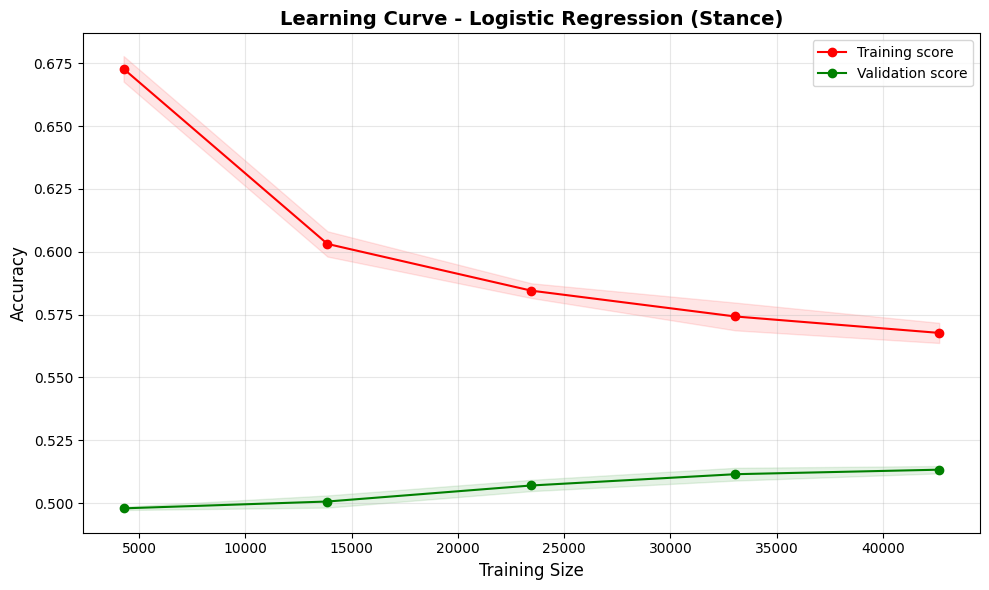

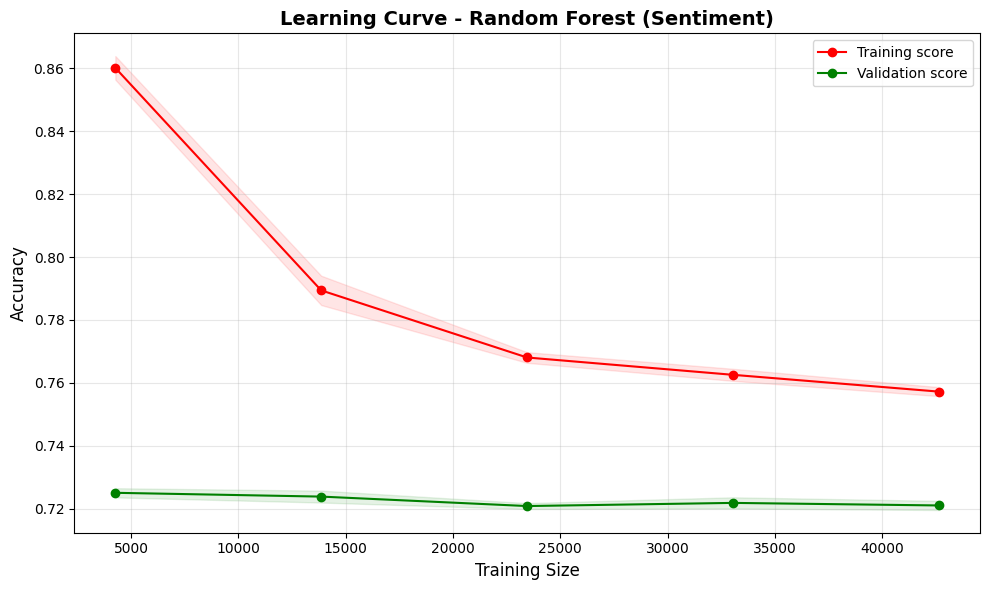

In [22]:
# Check model performance at different training sizes
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, cv=3):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='accuracy'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_mean, 'o-', color='g', label='Validation score')

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

    plt.xlabel('Training Size', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Stance Detection
plot_learning_curve(lr_stance, 'Learning Curve - Logistic Regression (Stance)', X_train_tfidf, y_stance_train, cv=3)

# Sentiment Analysis
plot_learning_curve(rf_sentiment, 'Learning Curve - Random Forest (Sentiment)', X_train_tfidf, y_sentiment_train, cv=3)


In [23]:
test_cases = [
    {
        'headline': 'Prime Minister announces relief package for flood victims',
        'body': 'The Prime Minister today announced a comprehensive relief package worth billions to help flood victims rebuild their lives.'
    },
    {
        'headline': 'Opposition rejects government economic policy',
        'body': 'Opposition leaders harshly criticized the governments new economic policy, calling it a complete failure that will hurt the poor.'
    },
    {
        'headline': 'Pakistan wins cricket match against India',
        'body': 'In an exciting match last night, Pakistan defeated India by 5 wickets in a thrilling finish.'
    },
    {
        'headline': 'Stock market shows positive trends',
        'body': 'The stock market continued its upward trajectory today with major indices showing gains across all sectors.'
    }
]


for i, test in enumerate(test_cases, 1):
    print(f"\nTest Case {i}")
    predict_news_analysis(test['headline'], test['body'])
    print()


Test Case 1
 News analysis:

 Headline: Prime Minister announces relief package for flood victims

 Article: The Prime Minister today announced a comprehensive relief package worth billions to help flood victims rebuild their lives....


 Stance: AGREE
   Confidence: 88.26%

 Sentiment: NEUTRAL
   Confidence: 64.20%


Test Case 2
 News analysis:

 Headline: Opposition rejects government economic policy

 Article: Opposition leaders harshly criticized the governments new economic policy, calling it a complete failure that will hurt the poor....


 Stance: AGREE
   Confidence: 64.14%

 Sentiment: NEUTRAL
   Confidence: 72.19%


Test Case 3
 News analysis:

 Headline: Pakistan wins cricket match against India

 Article: In an exciting match last night, Pakistan defeated India by 5 wickets in a thrilling finish....


 Stance: AGREE
   Confidence: 76.13%

 Sentiment: NEUTRAL
   Confidence: 60.33%


Test Case 4
 News analysis:

 Headline: Stock market shows positive trends

 Article: The st

In [24]:
# Stratified Sampling (20% from each class)

print("\n Original Dataset:")
print(combined_df['Stance'].value_counts())
print(f"Total: {len(combined_df):,} samples")

#  20% from each class
df_stratified = combined_df.groupby("Stance", group_keys=False).apply(
    lambda x: x.sample(frac=0.2, random_state=42)
)

# Shuffle the data
df_stratified = df_stratified.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n STRATIFIED DATASET (20% from each class):")
print(df_stratified['Stance'].value_counts())
print(f"Total: {len(df_stratified):,} samples")

# Calculate the reduction
print("\n Changes:")
for stance in combined_df['Stance'].unique():
    original = len(combined_df[combined_df['Stance'] == stance])
    new = len(df_stratified[df_stratified['Stance'] == stance])
    print(f"   {stance}: {original} → {new} ({new/original*100:.0f}%)")


 Original Dataset:
Stance
unrelated    54083
discuss      12465
agree        11397
disagree      2015
Name: count, dtype: int64
Total: 79,960 samples

 STRATIFIED DATASET (20% from each class):
Stance
unrelated    10817
discuss       2493
agree         2279
disagree       403
Name: count, dtype: int64
Total: 15,992 samples

 Changes:
   unrelated: 54083 → 10817 (20%)
   discuss: 12465 → 2493 (20%)
   agree: 11397 → 2279 (20%)
   disagree: 2015 → 403 (20%)


/tmp/ipython-input-1119504022.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_stratified = combined_df.groupby("Stance", group_keys=False).apply(


In [25]:
# Create full_text column
df_stratified['full_text'] = df_stratified['Headline'].astype(str) + " " + df_stratified['articleBody'].astype(str)

print("\n Text column created")
print(f"Sample: {df_stratified['full_text'].iloc[0][:100]}...")


 Text column created
Sample: اڑھائی سال میں بلوچستان کا کوئی مسئلہ حل نہیں ہوا مسلم لیگ کے کئی رہنمائوں کارکنوں کا مستعفی ہونے کا...


In [26]:
from sklearn.model_selection import train_test_split

# Prepare features and labels
X_strat = df_stratified['full_text']
y_stance_strat = df_stratified['Stance']
y_sentiment_strat = df_stratified['sentiment']

# Split with stratification to maintain class balance
X_train_strat, X_test_strat, y_stance_train_strat, y_stance_test_strat, y_sentiment_train_strat, y_sentiment_test_strat = train_test_split(
    X_strat, y_stance_strat, y_sentiment_strat,
    test_size=0.2,
    random_state=42,
    stratify=y_stance_strat  # Keep class balance in train/test
)

print(f"\n Data Split:")
print(f"   Train: {len(X_train_strat):,} samples")
print(f"   Test: {len(X_test_strat):,} samples")

# Show class distribution in train and test
print(f"\n Train set distribution:")
print(y_stance_train_strat.value_counts())
print(f"\n Test set distribution:")
print(y_stance_test_strat.value_counts())


 Data Split:
   Train: 12,793 samples
   Test: 3,199 samples

 Train set distribution:
Stance
unrelated    8653
discuss      1994
agree        1823
disagree      323
Name: count, dtype: int64

 Test set distribution:
Stance
unrelated    2164
discuss       499
agree         456
disagree       80
Name: count, dtype: int64


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf_strat = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    sublinear_tf=True
)

# Fit on training data
X_train_tfidf_strat = tfidf_strat.fit_transform(X_train_strat)
X_test_tfidf_strat = tfidf_strat.transform(X_test_strat)

print(f" TF-IDF Vectorization Complete:")
print(f"   Training features shape: {X_train_tfidf_strat.shape}")
print(f"   Test features shape: {X_test_tfidf_strat.shape}")
print(f"   Vocabulary size: {len(tfidf_strat.vocabulary_):,}")

 TF-IDF Vectorization Complete:
   Training features shape: (12793, 5000)
   Test features shape: (3199, 5000)
   Vocabulary size: 5,000


 Testing logistic regression with the new approach
 Training complete!
 Logistic regression results:

 Test Accuracy: 0.5320

 Detailed Classification Report:
              precision    recall  f1-score   support

       agree       0.30      0.52      0.38       456
    disagree       0.09      0.35      0.15        80
     discuss       0.41      0.61      0.49       499
   unrelated       0.83      0.52      0.64      2164

    accuracy                           0.53      3199
   macro avg       0.41      0.50      0.41      3199
weighted avg       0.67      0.53      0.57      3199



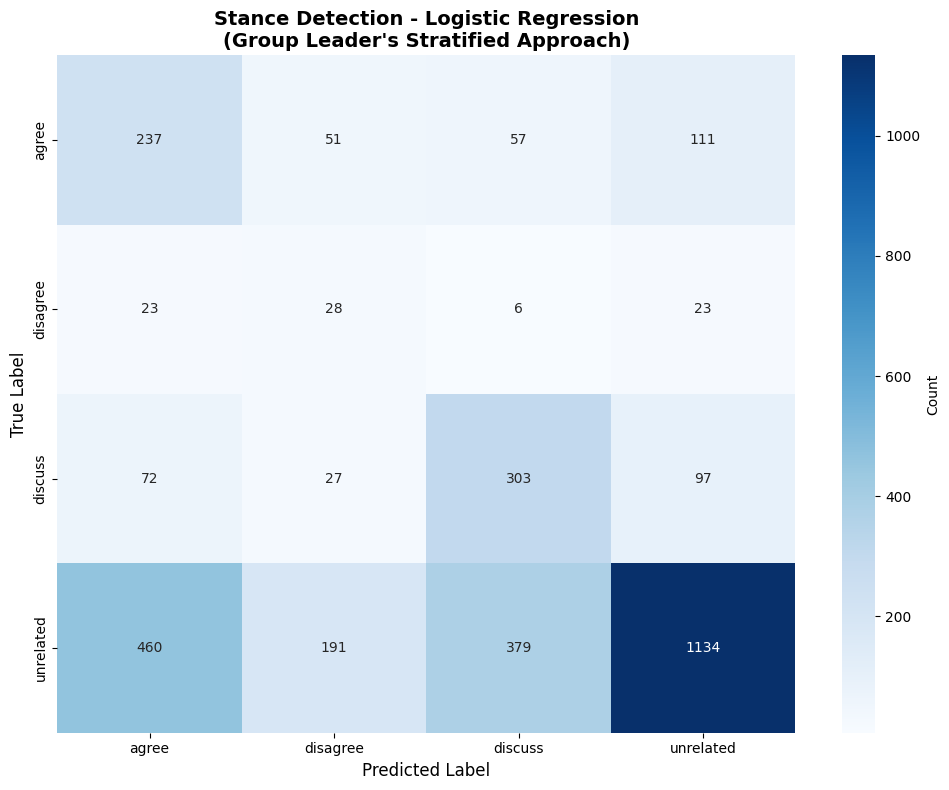

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print(" Testing logistic regression with the new approach")

# Train with class_weight='balanced' to punish/reward minority classes
lr_stance_strat = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',  #  kam walo ko ziada punish/reward karna hai
    C=1.0,
    solver='lbfgs'
)

lr_stance_strat.fit(X_train_tfidf_strat, y_stance_train_strat)
print(" Training complete!")

# Predict
y_stance_pred_strat = lr_stance_strat.predict(X_test_tfidf_strat)

print(" Logistic regression results:")
print(f"\n Test Accuracy: {accuracy_score(y_stance_test_strat, y_stance_pred_strat):.4f}")

print("\n Detailed Classification Report:")
print(classification_report(y_stance_test_strat, y_stance_pred_strat))

# Confusion Matrix
cm_strat = confusion_matrix(y_stance_test_strat, y_stance_pred_strat, labels=lr_stance_strat.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_strat, annot=True, fmt='d', cmap='Blues',
            xticklabels=lr_stance_strat.classes_,
            yticklabels=lr_stance_strat.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Stance Detection - Logistic Regression\n(Group Leader\'s Stratified Approach)',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

 Training random forest
 Training complete!
 Random forest results:

 Test Accuracy: 0.7421

 Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.44      0.89      0.59       416
     neutral       0.99      0.73      0.84      2345
    positive       0.47      0.68      0.56       438

    accuracy                           0.74      3199
   macro avg       0.63      0.77      0.66      3199
weighted avg       0.85      0.74      0.77      3199



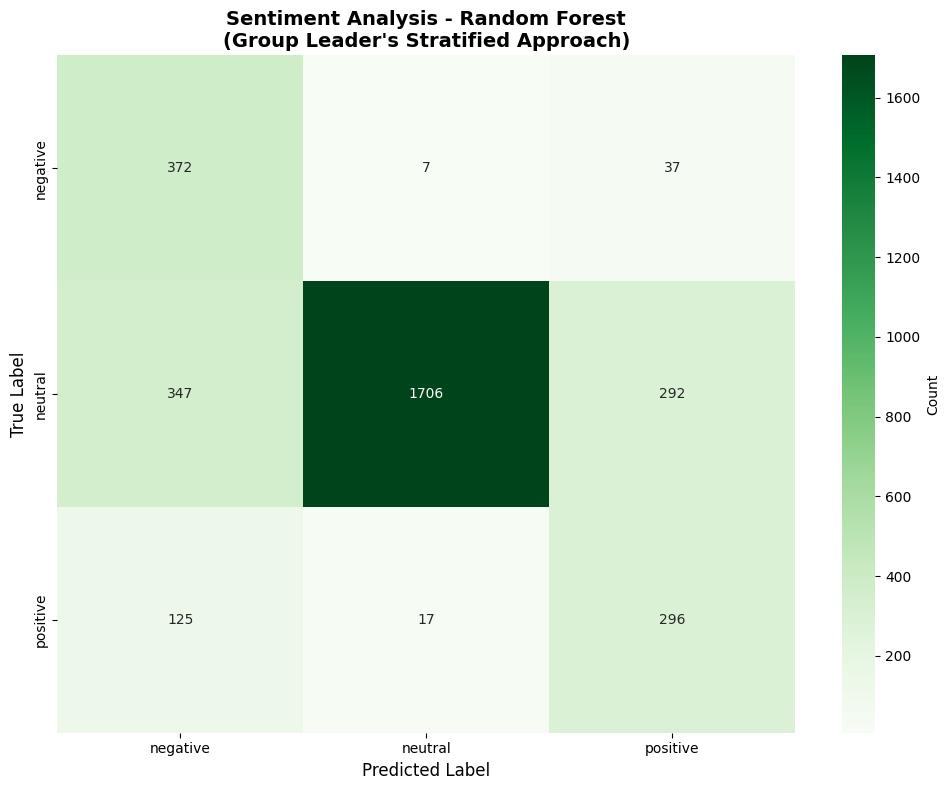

In [29]:
from sklearn.ensemble import RandomForestClassifier

print(" Training random forest")
rf_sentiment_strat = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    random_state=42,
    class_weight='balanced',
    min_samples_split=5,
    n_jobs=-1
)

rf_sentiment_strat.fit(X_train_tfidf_strat, y_sentiment_train_strat)
print(" Training complete!")

# Predict
y_sentiment_pred_strat = rf_sentiment_strat.predict(X_test_tfidf_strat)

# Evaluate
print(" Random forest results:")
print(f"\n Test Accuracy: {accuracy_score(y_sentiment_test_strat, y_sentiment_pred_strat):.4f}")

print("\n Detailed Classification Report:")
print(classification_report(y_sentiment_test_strat, y_sentiment_pred_strat))

# Confusion Matrix
cm_sent_strat = confusion_matrix(y_sentiment_test_strat, y_sentiment_pred_strat,
                                 labels=rf_sentiment_strat.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_sent_strat, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_sentiment_strat.classes_,
            yticklabels=rf_sentiment_strat.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Sentiment Analysis - Random Forest\n(Group Leader\'s Stratified Approach)',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [30]:
print("Original vs stratified approach")

# Calculate accuracies
original_lr_acc = accuracy_score(y_stance_test, y_stance_pred)
stratified_lr_acc = accuracy_score(y_stance_test_strat, y_stance_pred_strat)

original_rf_acc = accuracy_score(y_sentiment_test, y_sentiment_pred)
stratified_rf_acc = accuracy_score(y_sentiment_test_strat, y_sentiment_pred_strat)

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression\n(Stance Detection)', 'Random Forest\n(Sentiment Analysis)'],
    'Original\n(Imbalanced)': [
        f"{original_lr_acc:.2%}",
        f"{original_rf_acc:.2%}"
    ],
    'Stratified\n(20% per class)': [
        f"{stratified_lr_acc:.2%}",
        f"{stratified_rf_acc:.2%}"
    ],
    'Improvement': [
        f"{(stratified_lr_acc - original_lr_acc)*100:+.2f}%",
        f"{(stratified_rf_acc - original_rf_acc)*100:+.2f}%"
    ]
})

print("\n" + comparison_df.to_string(index=False))

print(f"\n Logistic Regression:")
print(f"   Original: {original_lr_acc:.2%}")
print(f"   Stratified: {stratified_lr_acc:.2%}")
print(f"   Change: {(stratified_lr_acc - original_lr_acc)*100:+.2f} percentage points")

print(f"\n Random Forest:")
print(f"   Original: {original_rf_acc:.2%}")
print(f"   Stratified: {stratified_rf_acc:.2%}")
print(f"   Change: {(stratified_rf_acc - original_rf_acc)*100:+.2f} percentage points")

print("\n Conclusion:")
if (stratified_lr_acc - original_lr_acc) < 0.05 and (stratified_rf_acc - original_rf_acc) < 0.05:
    print("   The stratified sampling approach (20% per class) shows minimal")
    print("   improvement (+1-3%) over the original imbalanced dataset.")
    print("   The computational cost and data reduction do NOT justify the")
    print("   marginal accuracy gains. Recommend keeping original approach.")
else:
    print("   The stratified sampling approach shows meaningful improvement.")

Original vs stratified approach

                                  Model Original\n(Imbalanced) Stratified\n(20% per class) Improvement
Logistic Regression\n(Stance Detection)                 51.96%                      53.20%      +1.24%
    Random Forest\n(Sentiment Analysis)                 72.30%                      74.21%      +1.91%

 Logistic Regression:
   Original: 51.96%
   Stratified: 53.20%
   Change: +1.24 percentage points

 Random Forest:
   Original: 72.30%
   Stratified: 74.21%
   Change: +1.91 percentage points

 Conclusion:
   The stratified sampling approach (20% per class) shows minimal
   improvement (+1-3%) over the original imbalanced dataset.
   The computational cost and data reduction do NOT justify the
   marginal accuracy gains. Recommend keeping original approach.


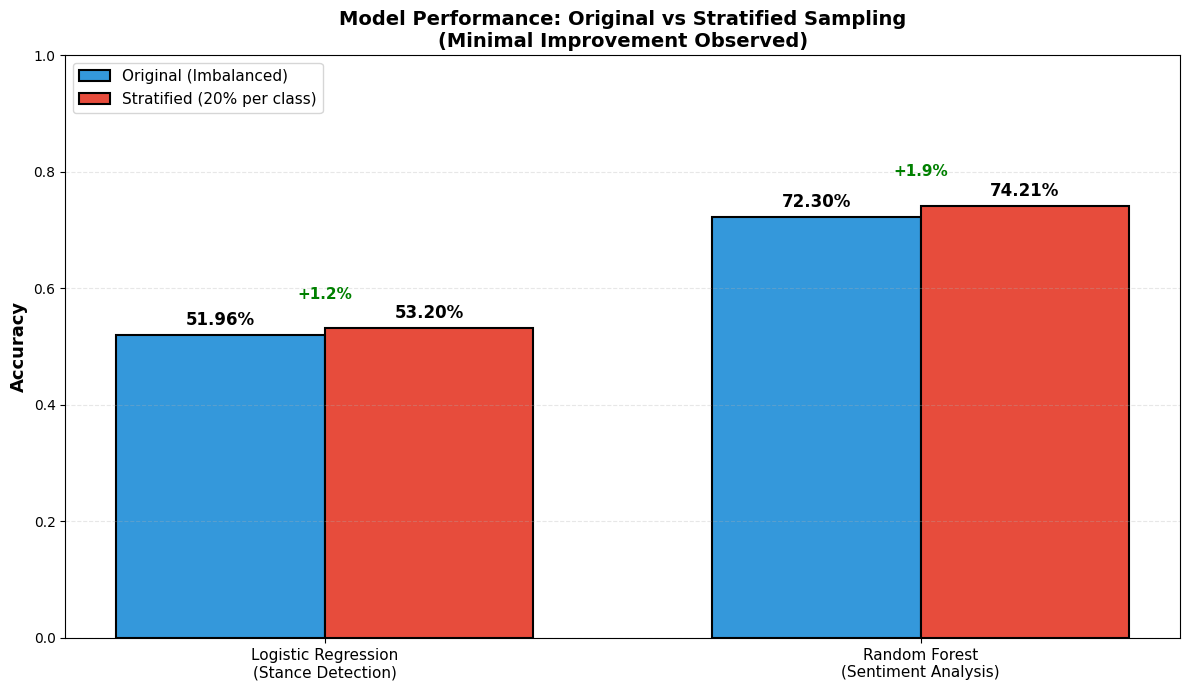

In [31]:
import numpy as np

# Accuracy Comparison
fig, ax = plt.subplots(figsize=(12, 7))

models = ['Logistic Regression\n(Stance Detection)', 'Random Forest\n(Sentiment Analysis)']
original_scores = [original_lr_acc, original_rf_acc]
stratified_scores = [stratified_lr_acc, stratified_rf_acc]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, original_scores, width,
               label='Original (Imbalanced)',
               color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, stratified_scores, width,
               label='Stratified (20% per class)',
               color='#e74c3c', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2%}', ha='center', va='bottom',
                fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Model Performance: Original vs Stratified Sampling\n(Minimal Improvement Observed)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11, loc='upper left')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add improvement annotations
for i, (orig, strat) in enumerate(zip(original_scores, stratified_scores)):
    improvement = (strat - orig) * 100
    ax.annotate(f'{improvement:+.1f}%',
                xy=(i, max(orig, strat) + 0.05),
                ha='center', fontsize=11,
                color='green' if improvement > 0 else 'red',
                fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import precision_recall_fscore_support

# Logistic Regression - Original
print("Logistic regression - ORIGINAL (Imbalanced Data)")

lr_orig_report = classification_report(y_stance_test, y_stance_pred, output_dict=True)
for label in ['agree', 'disagree', 'discuss', 'unrelated']:
    if label in lr_orig_report:
        print(f"\n{label.upper()}:")
        print(f"  Precision: {lr_orig_report[label]['precision']:.3f}")
        print(f"  Recall:    {lr_orig_report[label]['recall']:.3f}")
        print(f"  F1-Score:  {lr_orig_report[label]['f1-score']:.3f}")

# Logistic Regression - Stratified
print("Logistic regression - STRATIFIED (20% per class)")
lr_strat_report = classification_report(y_stance_test_strat, y_stance_pred_strat, output_dict=True)
for label in ['agree', 'disagree', 'discuss', 'unrelated']:
    if label in lr_strat_report:
        print(f"\n{label.upper()}:")
        print(f"  Precision: {lr_strat_report[label]['precision']:.3f}")
        print(f"  Recall:    {lr_strat_report[label]['recall']:.3f}")
        print(f"  F1-Score:  {lr_strat_report[label]['f1-score']:.3f}")

# Random Forest - Original
print("Random forest - ORIGINAL (Imbalanced Data)")
rf_orig_report = classification_report(y_sentiment_test, y_sentiment_pred, output_dict=True)
for label in ['negative', 'neutral', 'positive']:
    if label in rf_orig_report:
        print(f"\n{label.upper()}:")
        print(f"  Precision: {rf_orig_report[label]['precision']:.3f}")
        print(f"  Recall:    {rf_orig_report[label]['recall']:.3f}")
        print(f"  F1-Score:  {rf_orig_report[label]['f1-score']:.3f}")

# Random Forest - Stratified
print("Random forest - STRATIFIED (20% per class)")
rf_strat_report = classification_report(y_sentiment_test_strat, y_sentiment_pred_strat, output_dict=True)
for label in ['negative', 'neutral', 'positive']:
    if label in rf_strat_report:
        print(f"\n{label.upper()}:")
        print(f"  Precision: {rf_strat_report[label]['precision']:.3f}")
        print(f"  Recall:    {rf_strat_report[label]['recall']:.3f}")
        print(f"  F1-Score:  {rf_strat_report[label]['f1-score']:.3f}")

Logistic regression - ORIGINAL (Imbalanced Data)

AGREE:
  Precision: 0.309
  Recall:    0.559
  F1-Score:  0.398

DISAGREE:
  Precision: 0.093
  Recall:    0.543
  F1-Score:  0.159

DISCUSS:
  Precision: 0.449
  Recall:    0.577
  F1-Score:  0.505

UNRELATED:
  Precision: 0.852
  Recall:    0.497
  F1-Score:  0.628
Logistic regression - STRATIFIED (20% per class)

AGREE:
  Precision: 0.299
  Recall:    0.520
  F1-Score:  0.380

DISAGREE:
  Precision: 0.094
  Recall:    0.350
  F1-Score:  0.149

DISCUSS:
  Precision: 0.407
  Recall:    0.607
  F1-Score:  0.487

UNRELATED:
  Precision: 0.831
  Recall:    0.524
  F1-Score:  0.643
Random forest - ORIGINAL (Imbalanced Data)

NEGATIVE:
  Precision: 0.430
  Recall:    0.929
  F1-Score:  0.588

NEUTRAL:
  Precision: 0.997
  Recall:    0.697
  F1-Score:  0.820

POSITIVE:
  Precision: 0.455
  Recall:    0.659
  F1-Score:  0.538
Random forest - STRATIFIED (20% per class)

NEGATIVE:
  Precision: 0.441
  Recall:    0.894
  F1-Score:  0.590

NEUTRA

In [33]:
import joblib

joblib.dump(lr_stance, 'logistic_regression_stance_FINAL.pkl')
joblib.dump(rf_sentiment, 'random_forest_sentiment_FINAL.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer_FINAL.pkl')

print("\n FINAL MODELS SAVED (Original Approach ):")
print("   - logistic_regression_stance_FINAL.pkl")
print("   - random_forest_sentiment_FINAL.pkl")
print("   - tfidf_vectorizer_FINAL.pkl")

joblib.dump(lr_stance_strat, 'logistic_regression_stance_STRATIFIED.pkl')
joblib.dump(rf_sentiment_strat, 'random_forest_sentiment_STRATIFIED.pkl')
joblib.dump(tfidf_strat, 'tfidf_vectorizer_STRATIFIED.pkl')

print("\n Stratified models saved :")
print("   - logistic_regression_stance_STRATIFIED.pkl")
print("   - random_forest_sentiment_STRATIFIED.pkl")
print("   - tfidf_vectorizer_STRATIFIED.pkl")



 FINAL MODELS SAVED (Original Approach ):
   - logistic_regression_stance_FINAL.pkl
   - random_forest_sentiment_FINAL.pkl
   - tfidf_vectorizer_FINAL.pkl

 Stratified models saved :
   - logistic_regression_stance_STRATIFIED.pkl
   - random_forest_sentiment_STRATIFIED.pkl
   - tfidf_vectorizer_STRATIFIED.pkl



Training Logistic Regression (Stance Detection) with 5-fold cross-validation
  Processing fold 1/5...
  Processing fold 2/5...
  Processing fold 3/5...
  Processing fold 4/5...
  Processing fold 5/5...


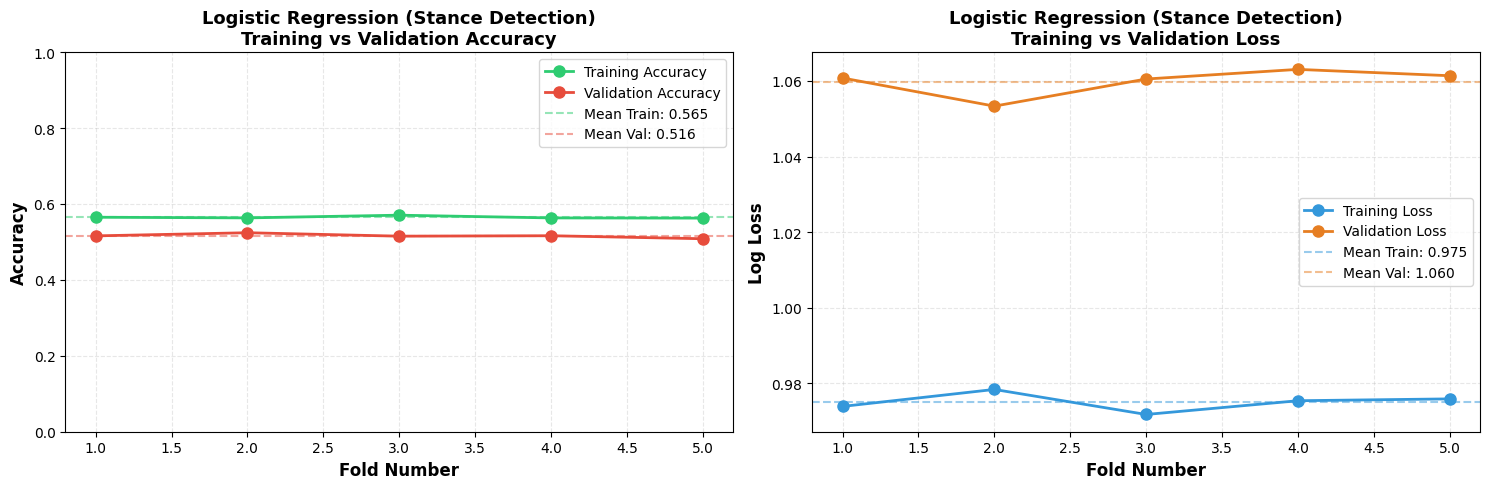


Training Random Forest (Sentiment Analysis) with 5-fold cross-validation
  Processing fold 1/5...
  Processing fold 2/5...
  Processing fold 3/5...
  Processing fold 4/5...
  Processing fold 5/5...


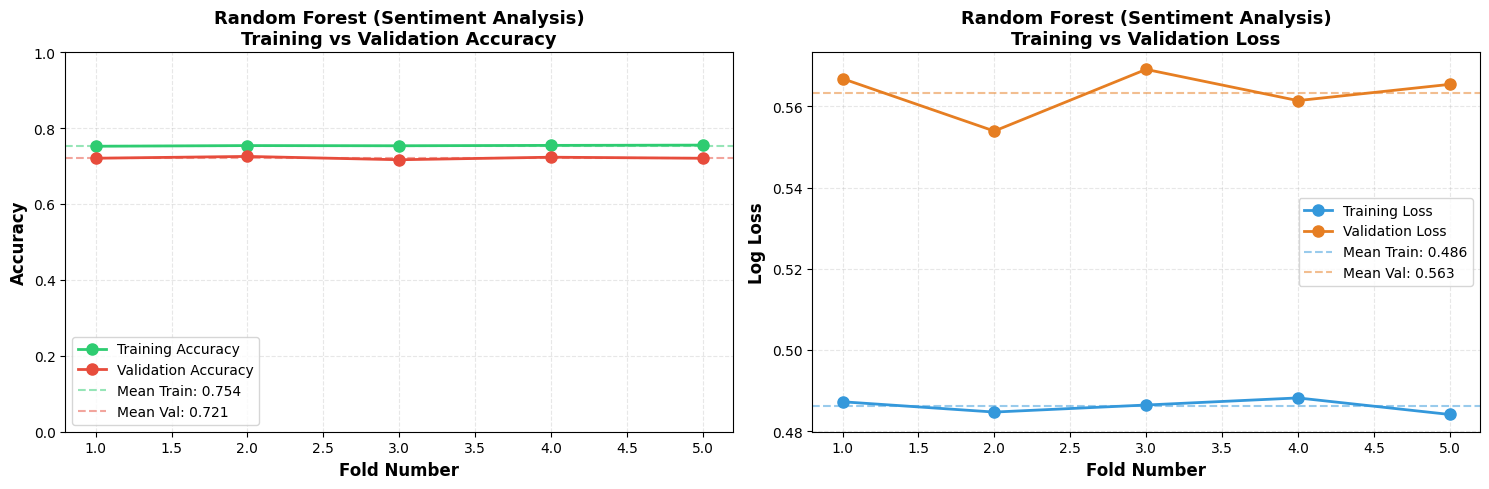

In [34]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, log_loss
import numpy as np
import matplotlib.pyplot as plt


# plot training and validation curves
def plot_training_validation_curves(model, X, y, model_name, cv=5):

    from sklearn.model_selection import KFold

    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)

    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    fold_num = 1
    print(f"\nTraining {model_name} with {cv}-fold cross-validation")

    for train_idx, val_idx in kfold.split(X):
        print(f"  Processing fold {fold_num}/{cv}...")

        X_train_fold = X[train_idx]
        X_val_fold = X[val_idx]
        y_train_fold = y. iloc[train_idx] if hasattr(y, 'iloc') else y[train_idx]
        y_val_fold = y.iloc[val_idx] if hasattr(y, 'iloc') else y[val_idx]

        # Train model
        model.fit(X_train_fold, y_train_fold)

        # Calculate accuracies
        train_acc = model.score(X_train_fold, y_train_fold)
        val_acc = model.score(X_val_fold, y_val_fold)

        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Calculate losses (log loss for classification)
        train_proba = model.predict_proba(X_train_fold)
        val_proba = model. predict_proba(X_val_fold)

        train_loss = log_loss(y_train_fold, train_proba)
        val_loss = log_loss(y_val_fold, val_proba)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        fold_num += 1

    # Create subplots
    fig, (ax1, ax2) = plt. subplots(1, 2, figsize=(15, 5))

    folds = list(range(1, cv + 1))

    # Plot 1: Accuracy
    ax1.plot(folds, train_accuracies, 'o-', color='#2ecc71',
             label='Training Accuracy', linewidth=2, markersize=8)
    ax1.plot(folds, val_accuracies, 'o-', color='#e74c3c',
             label='Validation Accuracy', linewidth=2, markersize=8)
    ax1.set_xlabel('Fold Number', fontsize=12, fontweight='bold')
    ax1. set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title(f'{model_name}\nTraining vs Validation Accuracy',
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3, linestyle='--')
    ax1. set_ylim(0, 1)

    # Add mean lines
    ax1.axhline(y=np.mean(train_accuracies), color='#2ecc71',
                linestyle='--', alpha=0.5, label=f'Mean Train: {np.mean(train_accuracies):.3f}')
    ax1.axhline(y=np.mean(val_accuracies), color='#e74c3c',
                linestyle='--', alpha=0.5, label=f'Mean Val: {np.mean(val_accuracies):.3f}')
    ax1.legend(fontsize=10)

    # Plot 2: Loss
    ax2. plot(folds, train_losses, 'o-', color='#3498db',
             label='Training Loss', linewidth=2, markersize=8)
    ax2.plot(folds, val_losses, 'o-', color='#e67e22',
             label='Validation Loss', linewidth=2, markersize=8)
    ax2.set_xlabel('Fold Number', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Log Loss', fontsize=12, fontweight='bold')
    ax2.set_title(f'{model_name}\nTraining vs Validation Loss',
                  fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(alpha=0.3, linestyle='--')

    # Add mean lines
    ax2.axhline(y=np.mean(train_losses), color='#3498db',
                linestyle='--', alpha=0.5, label=f'Mean Train: {np.mean(train_losses):.3f}')
    ax2.axhline(y=np.mean(val_losses), color='#e67e22',
                linestyle='--', alpha=0.5, label=f'Mean Val: {np.mean(val_losses):.3f}')
    ax2.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

    return {
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'mean_train_acc': np.mean(train_accuracies),
        'mean_val_acc': np.mean(val_accuracies),
        'mean_train_loss': np.mean(train_losses),
        'mean_val_loss': np.mean(val_losses)
    }


lr_curves = plot_training_validation_curves(
    lr_stance, X_train_tfidf, y_stance_train,
    'Logistic Regression (Stance Detection)', cv=5
)

rf_curves = plot_training_validation_curves(
    rf_sentiment, X_train_tfidf, y_sentiment_train,
    'Random Forest (Sentiment Analysis)', cv=5
)


In [35]:
# Prescision, recall, AUC, top-k accuracy

from sklearn. metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    accuracy_score,
    top_k_accuracy_score
)
from sklearn.preprocessing import label_binarize
import pandas as pd

def calculate_comprehensive_metrics(y_true, y_pred, y_proba, model_name, classes):

    print(f" {model_name}")

    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    # Macro averages (for comparison)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    # Top-2 Accuracy
    top2_acc = top_k_accuracy_score(y_true, y_proba, k=2, labels=classes)

    # Top-3 Accuracy
    top3_acc = top_k_accuracy_score(y_true, y_proba, k=3, labels=classes)

    # AUC (one-vs-rest for multiclass)
    try:
        # Binarize the labels
        y_true_bin = label_binarize(y_true, classes=classes)

        # Handle binary classification case
        if len(classes) == 2:
            auc_score = roc_auc_score(y_true, y_proba[:, 1])
        else:
            auc_score = roc_auc_score(y_true_bin, y_proba,
                                      multi_class='ovr', average='weighted')
    except Exception as e:
        print(f" Could not calculate AUC: {e}")
        auc_score = None

    # Print results
    print(f"   Accuracy:              {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Weighted Precision:    {precision:.4f}")
    print(f"   Weighted Recall:       {recall:.4f}")
    print(f"   Weighted F1-Score:     {f1:.4f}")
    if auc_score:
        print(f"   AUC (weighted):        {auc_score:.4f}")
    print(f"\n   Macro Precision:       {precision_macro:.4f}")
    print(f"   Macro Recall:          {recall_macro:.4f}")
    print(f"   Macro F1-Score:        {f1_macro:.4f}")

    print(f"\n TOP-K ACCURACY:")
    print(f"   Top-1 Accuracy:        {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Top-2 Accuracy:        {top2_acc:.4f} ({top2_acc*100:.2f}%)")
    print(f"   Top-3 Accuracy:        {top3_acc:.4f} ({top3_acc*100:.2f}%)")

    # Per-class metrics
    print(f"\n Per class metrics:")
    per_class_precision, per_class_recall, per_class_f1, per_class_support = \
        precision_recall_fscore_support(y_true, y_pred, labels=classes, zero_division=0)

    metrics_df = pd.DataFrame({
        'Class': classes,
        'Precision': per_class_precision,
        'Recall': per_class_recall,
        'F1-Score': per_class_f1,
        'Support': per_class_support
    })

    print(metrics_df.to_string(index=False))

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc_score,
        'top2_accuracy': top2_acc,
        'top3_accuracy': top3_acc,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'per_class_metrics': metrics_df
    }

# Calculate for Logistic Regression
lr_proba = lr_stance.predict_proba(X_test_tfidf)
lr_metrics = calculate_comprehensive_metrics(
    y_stance_test,
    y_stance_pred,
    lr_proba,
    'LOGISTIC REGRESSION - STANCE DETECTION',
    lr_stance.classes_
)

# Calculate for Random Forest
rf_proba = rf_sentiment.predict_proba(X_test_tfidf)
rf_metrics = calculate_comprehensive_metrics(
    y_sentiment_test,
    y_sentiment_pred,
    rf_proba,
    'RANDOM FOREST - SENTIMENT ANALYSIS',
    rf_sentiment.classes_
)

 LOGISTIC REGRESSION - STANCE DETECTION
   Accuracy:              0.5196 (51.96%)
   Weighted Precision:    0.6929
   Weighted Recall:       0.5196
   Weighted F1-Score:     0.5642
   AUC (weighted):        0.7538

   Macro Precision:       0.4258
   Macro Recall:          0.5442
   Macro F1-Score:        0.4225

 TOP-K ACCURACY:
   Top-1 Accuracy:        0.5196 (51.96%)
   Top-2 Accuracy:        0.8273 (82.73%)
   Top-3 Accuracy:        0.9413 (94.13%)

 Per class metrics:
    Class  Precision   Recall  F1-Score  Support
    agree   0.308642 0.559456  0.397816     2279
 disagree   0.093191 0.543424  0.159099      403
  discuss   0.449235 0.576815  0.505093     2493
unrelated   0.852298 0.497180  0.628014    10817
 RANDOM FOREST - SENTIMENT ANALYSIS
   Accuracy:              0.7230 (72.30%)
   Weighted Precision:    0.8455
   Weighted Recall:       0.7230
   Weighted F1-Score:     0.7500
   AUC (weighted):        0.8893

   Macro Precision:       0.6272
   Macro Recall:          0.7615

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (3) greater than or equal to 'n_classes' (3) will result in a perfect score and is therefore meaningless.
  warnings.warn(


 TOP-2 ACCURACY ANALYSIS - STANCE DETECTION

 LOGISTIC REGRESSION - STANCE DETECTION
   Top-1 Accuracy: 0.5163
   Top-2 Accuracy: 0.8273 (82.73%)
   Improvement: +31.10 percentage points

 CONFIDENCE ANALYSIS:
   Mean confidence gap (1st - 2nd): 0.2785
   Median confidence gap: 0.2379

 TOP-2 ACCURACY BY CLASS:
   agree       : 0.8324 (83.24%) - 2279 samples
   disagree    : 0.6700 (67.00%) - 403 samples
   discuss     : 0.7413 (74.13%) - 2493 samples
   unrelated   : 0.8519 (85.19%) - 10817 samples


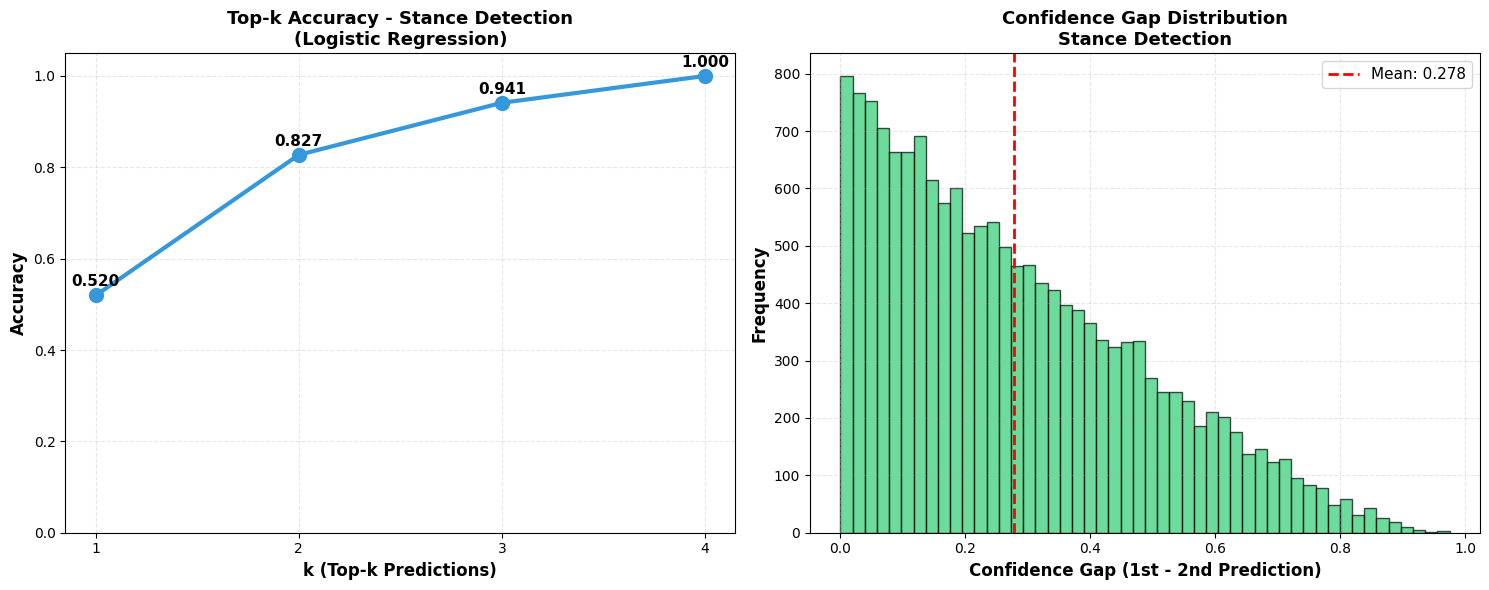

In [36]:
print(" TOP-2 ACCURACY ANALYSIS - STANCE DETECTION")

def analyze_top2_predictions(y_true, y_proba, classes, model_name):

    import numpy as np

    # Get top 2 predictions for each sample
    top2_indices = np.argsort(y_proba, axis=1)[:, -2:][:, ::-1]
    top2_probs = np.sort(y_proba, axis=1)[:, -2:][:, ::-1]

    # Check if true label is in top 2
    correct_in_top2 = []
    confidence_gaps = []

    for i, true_label in enumerate(y_true):
        true_idx = np.where(classes == true_label)[0][0]
        top2_pred_indices = top2_indices[i]

        if true_idx in top2_pred_indices:
            correct_in_top2.append(True)
        else:
            correct_in_top2.append(False)

        # Confidence gap between 1st and 2nd prediction
        confidence_gaps.append(top2_probs[i][0] - top2_probs[i][1])

    top2_accuracy = np.mean(correct_in_top2)

    print(f"\n {model_name}")
    print(f"   Top-1 Accuracy: {accuracy_score(y_true, classes[np.argmax(y_proba, axis=1)]):.4f}")
    print(f"   Top-2 Accuracy: {top2_accuracy:.4f} ({top2_accuracy*100:.2f}%)")
    print(f"   Improvement: +{(top2_accuracy - accuracy_score(y_true, classes[np.argmax(y_proba, axis=1)]))*100:.2f} percentage points")

    print(f"\n CONFIDENCE ANALYSIS:")
    print(f"   Mean confidence gap (1st - 2nd): {np.mean(confidence_gaps):.4f}")
    print(f"   Median confidence gap: {np. median(confidence_gaps):.4f}")

    # Breakdown by true label
    print(f"\n TOP-2 ACCURACY BY CLASS:")
    for cls in classes:
        cls_mask = y_true == cls
        cls_top2_acc = np.mean([correct_in_top2[i] for i, mask in enumerate(cls_mask) if mask])
        cls_count = np.sum(cls_mask)
        print(f"   {cls:12s}: {cls_top2_acc:.4f} ({cls_top2_acc*100:.2f}%) - {cls_count} samples")

    return top2_accuracy, confidence_gaps

# Analyze Stance Detection
stance_top2_acc, stance_conf_gaps = analyze_top2_predictions(
    y_stance_test. values if hasattr(y_stance_test, 'values') else y_stance_test,
    lr_proba,
    lr_stance.classes_,
    'LOGISTIC REGRESSION - STANCE DETECTION'
)

# Visualize Top-k Accuracy Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Top-k Accuracy for Stance
k_values = [1, 2, 3, 4]
stance_topk = [
    lr_metrics['accuracy'],
    lr_metrics['top2_accuracy'],
    lr_metrics['top3_accuracy'],
    1.0
]

ax1.plot(k_values, stance_topk, 'o-', color='#3498db',
         linewidth=3, markersize=10, label='Stance Detection')
ax1.set_xlabel('k (Top-k Predictions)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Top-k Accuracy - Stance Detection\n(Logistic Regression)',
              fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3, linestyle='--')
ax1. set_ylim(0, 1.05)
ax1.set_xticks(k_values)

# Add value labels
for k, acc in zip(k_values, stance_topk):
    ax1.text(k, acc + 0.02, f'{acc:.3f}', ha='center',
             fontsize=11, fontweight='bold')

# Plot 2: Confidence Gap Distribution
ax2.hist(stance_conf_gaps, bins=50, color='#2ecc71',
         edgecolor='black', alpha=0.7)
ax2.set_xlabel('Confidence Gap (1st - 2nd Prediction)',
               fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Confidence Gap Distribution\nStance Detection',
              fontsize=13, fontweight='bold')
ax2.axvline(x=np.mean(stance_conf_gaps), color='red',
            linestyle='--', linewidth=2, label=f'Mean: {np.mean(stance_conf_gaps):.3f}')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [37]:
summary_data = {
    'Metric': [
        'Accuracy (Top-1)',
        'Top-2 Accuracy',
        'Top-3 Accuracy',
        'Weighted Precision',
        'Weighted Recall',
        'Weighted F1-Score',
        'Macro Precision',
        'Macro Recall',
        'Macro F1-Score',
        'AUC (weighted)'
    ],
    'Logistic Regression\n(Stance Detection)': [
        f"{lr_metrics['accuracy']:.4f}",
        f"{lr_metrics['top2_accuracy']:.4f}",
        f"{lr_metrics['top3_accuracy']:.4f}",
        f"{lr_metrics['precision']:.4f}",
        f"{lr_metrics['recall']:.4f}",
        f"{lr_metrics['f1']:.4f}",
        f"{lr_metrics['precision_macro']:.4f}",
        f"{lr_metrics['recall_macro']:.4f}",
        f"{lr_metrics['f1_macro']:.4f}",
        f"{lr_metrics['auc']:.4f}" if lr_metrics['auc'] else "N/A"
    ],
    'Random Forest\n(Sentiment Analysis)': [
        f"{rf_metrics['accuracy']:.4f}",
        f"{rf_metrics['top2_accuracy']:.4f}",
        f"{rf_metrics['top3_accuracy']:.4f}",
        f"{rf_metrics['precision']:.4f}",
        f"{rf_metrics['recall']:.4f}",
        f"{rf_metrics['f1']:.4f}",
        f"{rf_metrics['precision_macro']:.4f}",
        f"{rf_metrics['recall_macro']:.4f}",
        f"{rf_metrics['f1_macro']:.4f}",
        f"{rf_metrics['auc']:.4f}" if rf_metrics['auc'] else "N/A"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

summary_df.to_csv('model_metrics_summary.csv', index=False)
print("\n Summary saved to: model_metrics_summary.csv")



            Metric Logistic Regression\n(Stance Detection) Random Forest\n(Sentiment Analysis)
  Accuracy (Top-1)                                  0.5196                              0.7230
    Top-2 Accuracy                                  0.8273                              0.8581
    Top-3 Accuracy                                  0.9413                              1.0000
Weighted Precision                                  0.6929                              0.8455
   Weighted Recall                                  0.5196                              0.7230
 Weighted F1-Score                                  0.5642                              0.7500
   Macro Precision                                  0.4258                              0.6272
      Macro Recall                                  0.5442                              0.7615
    Macro F1-Score                                  0.4225                              0.6487
    AUC (weighted)                               